# Session 2 Quiz – Gradient Descent step by step

The quiz slides walk through the **first iteration** of gradient descent for a linear model by hand and
then end with: *"Second Iteration: repeat the process with updated values w = 0.182 and b = 0.0645."*

So in this notebook I:

1. write down the given data and formulas,
2. redo the first iteration by hand and check that I get the same numbers as the slides,
3. do the **second iteration by hand** (the actual quiz),
4. verify every number with numpy, and then let the loop run for many iterations to see where the line ends up.

> Note: the slide header says "Logistic Regression", but the model $\hat{y} = w\cdot x + b$ with the MSE
> loss is **linear regression** – it is the same algorithm as in the Session 1 lecture, just written with
> $w, b$ instead of $a_1, a_0$.

## Given

| $x$ | $y$ |
|---|---|
| 1 | 2 |
| 2 | 2.8 |
| 3 | 3.6 |
| 4 | 4.5 |

- Model: $\hat{y} = w\cdot x + b$ ($w$ = weight / slope, $b$ = bias / intercept)
- Loss (MSE): $L(w,b) = \dfrac{1}{n}\displaystyle\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$, with $n = 4$
- Gradients: $\dfrac{\partial L}{\partial w} = \dfrac{2}{n}\displaystyle\sum_{i=1}^{n}(\hat{y}_i - y_i)\,x_i
  \qquad \dfrac{\partial L}{\partial b} = \dfrac{2}{n}\displaystyle\sum_{i=1}^{n}(\hat{y}_i - y_i)$
- Update: $w \leftarrow w - \alpha\dfrac{\partial L}{\partial w} \qquad b \leftarrow b - \alpha\dfrac{\partial L}{\partial b}$
- Start: $w = 0$, $b = 0$, learning rate $\alpha = 0.01$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4], dtype=float)
y = np.array([2, 2.8, 3.6, 4.5])
alpha = 0.01
n = len(x)


def gd_step(w, b, x, y, alpha, verbose=True):
    # 1. predictions and errors
    y_hat = w * x + b
    error = y_hat - y
    mse = np.mean(error ** 2)
    # 2. gradients
    dL_dw = (2 / n) * np.sum(error * x)
    dL_db = (2 / n) * np.sum(error)
    # 3. update
    w_new = w - alpha * dL_dw
    b_new = b - alpha * dL_db
    if verbose:
        print(f"predictions y_hat   : {np.round(y_hat, 4)}")
        print(f"errors (y_hat - y)  : {np.round(error, 4)}")
        print(f"errors * x          : {np.round(error * x, 4)}")
        print(f"MSE before update   : {mse:.4f}")
        print(f"dL/dw = (2/{n}) * ({np.sum(error * x):.4f}) = {dL_dw:.4f}")
        print(f"dL/db = (2/{n}) * ({np.sum(error):.4f}) = {dL_db:.4f}")
        print(f"w_new = {w:.6g} - {alpha} * ({dL_dw:.4f}) = {w_new:.6f}")
        print(f"b_new = {b:.6g} - {alpha} * ({dL_db:.4f}) = {b_new:.6f}")
    return w_new, b_new, mse

## Iteration 1 (given in the slides – checking my understanding)

With $w = 0, b = 0$ all predictions are $\hat{y}_i = 0$, so every error is simply $-y_i$:

$$\frac{\partial L}{\partial w} = \frac{2}{4}\big[(-2)(1) + (-2.8)(2) + (-3.6)(3) + (-4.5)(4)\big]
= \frac{2}{4}(-36.4) = -18.2$$

$$\frac{\partial L}{\partial b} = \frac{2}{4}\big[-2 - 2.8 - 3.6 - 4.5\big] = \frac{2}{4}(-12.9) = -6.45$$

$$w = 0 - 0.01\cdot(-18.2) = 0.182 \qquad\qquad b = 0 - 0.01\cdot(-6.45) = 0.0645$$

The loss at the starting point is $L = \frac{1}{4}(2^2 + 2.8^2 + 3.6^2 + 4.5^2) = \frac{45.05}{4} = 11.2625$.

In [2]:
w1, b1, mse0 = gd_step(0.0, 0.0, x, y, alpha)

predictions y_hat   : [0. 0. 0. 0.]
errors (y_hat - y)  : [-2.  -2.8 -3.6 -4.5]
errors * x          : [ -2.   -5.6 -10.8 -18. ]
MSE before update   : 11.2625
dL/dw = (2/4) * (-36.4000) = -18.2000
dL/db = (2/4) * (-12.9000) = -6.4500
w_new = 0 - 0.01 * (-18.2000) = 0.182000
b_new = 0 - 0.01 * (-6.4500) = 0.064500


Same numbers as the slides ($w = 0.182$, $b = 0.0645$), so the formulas in `gd_step` are right.

## Iteration 2 – by hand (the quiz)

Start from $w = 0.182$, $b = 0.0645$.

**1. Predictions** $\hat{y}_i = 0.182\,x_i + 0.0645$

| $x_i$ | $\hat{y}_i$ | $y_i$ | error $\hat{y}_i - y_i$ | error $\times\, x_i$ |
|---|---|---|---|---|
| 1 | 0.182 + 0.0645 = **0.2465** | 2 | −1.7535 | −1.7535 |
| 2 | 0.364 + 0.0645 = **0.4285** | 2.8 | −2.3715 | −4.7430 |
| 3 | 0.546 + 0.0645 = **0.6105** | 3.6 | −2.9895 | −8.9685 |
| 4 | 0.728 + 0.0645 = **0.7925** | 4.5 | −3.7075 | −14.8300 |
| | | | **Σ = −10.822** | **Σ = −30.295** |

**2. Gradients**

$$\frac{\partial L}{\partial w} = \frac{2}{4}\,(-30.295) = -15.1475
\qquad\qquad
\frac{\partial L}{\partial b} = \frac{2}{4}\,(-10.822) = -5.411$$

**3. Update** ($\alpha = 0.01$)

$$w = 0.182 - 0.01\cdot(-15.1475) = 0.182 + 0.151475 = \mathbf{0.333475}$$

$$b = 0.0645 - 0.01\cdot(-5.411) = 0.0645 + 0.05411 = \mathbf{0.11861}$$

**Loss before this update:**
$L = \frac{1}{4}\left(1.7535^2 + 2.3715^2 + 2.9895^2 + 3.7075^2\right) = \frac{31.3814}{4} \approx 7.8454$,
lower than the 11.2625 of iteration 1 – so the first step really improved the model.

### Answer after the second iteration: $\;w = 0.333475,\quad b = 0.11861$

In [3]:
w2, b2, mse1 = gd_step(0.182, 0.0645, x, y, alpha)

predictions y_hat   : [0.2465 0.4285 0.6105 0.7925]
errors (y_hat - y)  : [-1.7535 -2.3715 -2.9895 -3.7075]
errors * x          : [ -1.7535  -4.743   -8.9685 -14.83  ]
MSE before update   : 7.8454
dL/dw = (2/4) * (-30.2950) = -15.1475
dL/db = (2/4) * (-10.8220) = -5.4110
w_new = 0.182 - 0.01 * (-15.1475) = 0.333475
b_new = 0.0645 - 0.01 * (-5.4110) = 0.118610


The code gives exactly the values I computed by hand: $w = 0.333475$ and $b = 0.11861$.

## Iteration 3 (one more, to see the pattern)

In [4]:
w3, b3, mse2 = gd_step(w2, b2, x, y, alpha)

predictions y_hat   : [0.4521 0.7856 1.119  1.4525]
errors (y_hat - y)  : [-1.5479 -2.0144 -2.481  -3.0475]
errors * x          : [ -1.5479  -4.0289  -7.4429 -12.19  ]
MSE before update   : 5.4741
dL/dw = (2/4) * (-25.2097) = -12.6048
dL/db = (2/4) * (-9.0908) = -4.5454
w_new = 0.333475 - 0.01 * (-12.6048) = 0.459523
b_new = 0.11861 - 0.01 * (-4.5454) = 0.164064


## What happens if we keep going?

Doing this by hand is painful, so I let the computer repeat the same three steps. I print the first 10
iterations as a table, then run 1,000 and 20,000 iterations with $\alpha = 0.01$, and 1,000 iterations
with a bigger $\alpha = 0.1$, and compare everything with the exact least-squares line (`np.polyfit`).

In [5]:
def train(alpha, n_iters, w=0.0, b=0.0):
    history = []
    for i in range(1, n_iters + 1):
        w_new, b_new, mse = gd_step(w, b, x, y, alpha, verbose=False)
        history.append({"iteration": i, "w (before)": w, "b (before)": b, "MSE (before)": mse,
                        "w (after)": w_new, "b (after)": b_new})
        w, b = w_new, b_new
    return w, b, pd.DataFrame(history).set_index("iteration")


_, _, first_10 = train(alpha=0.01, n_iters=10)
first_10.round(6)

,w (before),b (before),MSE (before),w (after),b (after)
iteration,,,,,
1,0.000000,0.000000,11.262500,0.182000,0.064500
2,0.182000,0.064500,7.845360,0.333475,0.118610
3,0.333475,0.118610,5.474098,0.459523,0.164064
4,0.459523,0.164064,3.828549,0.564392,0.202307
5,0.564392,0.202307,2.686558,0.651617,0.234541
6,0.651617,0.234541,1.893977,0.724148,0.261769
7,0.724148,0.261769,1.343845,0.784437,0.284826
8,0.784437,0.284826,0.961944,0.834530,0.304408
9,0.834530,0.304408,0.696776,0.876130,0.321093


In [6]:
w_1k, b_1k, hist_1k = train(alpha=0.01, n_iters=1_000)
w_20k, b_20k, hist_20k = train(alpha=0.01, n_iters=20_000)
w_fast, b_fast, hist_fast = train(alpha=0.1, n_iters=1_000)
slope, intercept = np.polyfit(x, y, 1)          # exact least-squares solution, for comparison

def mse_of(w, b):
    return np.mean((w * x + b - y) ** 2)

summary = pd.DataFrame([
    {"run": "after iteration 1",              "w": w1,        "b": b1,        "MSE": mse_of(w1, b1)},
    {"run": "after iteration 2 (the quiz)",   "w": w2,        "b": b2,        "MSE": mse_of(w2, b2)},
    {"run": "after iteration 3",              "w": w3,        "b": b3,        "MSE": mse_of(w3, b3)},
    {"run": "alpha=0.01, 1,000 iterations",   "w": w_1k,      "b": b_1k,      "MSE": mse_of(w_1k, b_1k)},
    {"run": "alpha=0.01, 20,000 iterations",  "w": w_20k,     "b": b_20k,     "MSE": mse_of(w_20k, b_20k)},
    {"run": "alpha=0.1, 1,000 iterations",    "w": w_fast,    "b": b_fast,    "MSE": mse_of(w_fast, b_fast)},
    {"run": "exact least squares (polyfit)",  "w": slope,     "b": intercept, "MSE": mse_of(slope, intercept)},
]).set_index("run")
summary.round(6)

,w,b,MSE
run,,,
after iteration 1,0.182000,0.064500,7.845360
after iteration 2 (the quiz),0.333475,0.118610,5.474098
after iteration 3,0.459523,0.164064,3.828549
"alpha=0.01, 1,000 iterations",0.843191,1.111217,0.001001
"alpha=0.01, 20,000 iterations",0.830000,1.150000,0.000750
"alpha=0.1, 1,000 iterations",0.830000,1.150000,0.000750
exact least squares (polyfit),0.830000,1.150000,0.000750


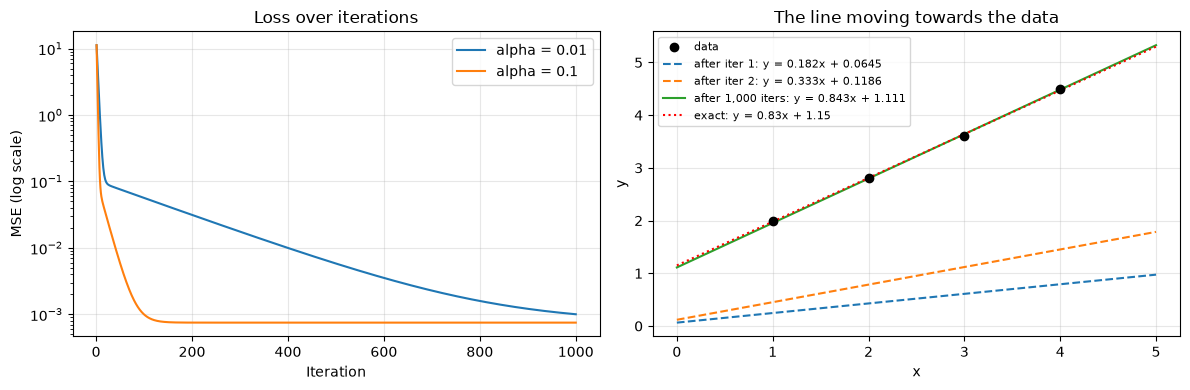

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_1k.index, hist_1k["MSE (before)"], label="alpha = 0.01")
ax1.plot(hist_fast.index, hist_fast["MSE (before)"], label="alpha = 0.1")
ax1.set_yscale("log")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("MSE (log scale)")
ax1.set_title("Loss over iterations")
ax1.legend()
ax1.grid(alpha=0.3)

x_line = np.linspace(0, 5, 50)
ax2.scatter(x, y, color="black", zorder=3, label="data")
ax2.plot(x_line, w1 * x_line + b1, "--", label=f"after iter 1: y = {w1:.3f}x + {b1:.4f}")
ax2.plot(x_line, w2 * x_line + b2, "--", label=f"after iter 2: y = {w2:.3f}x + {b2:.4f}")
ax2.plot(x_line, w_1k * x_line + b_1k, label=f"after 1,000 iters: y = {w_1k:.3f}x + {b_1k:.3f}")
ax2.plot(x_line, slope * x_line + intercept, ":", color="red", label=f"exact: y = {slope:.2f}x + {intercept:.2f}")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("The line moving towards the data")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations**

- Both gradients are negative at the beginning because the predictions are *below* the real values
  ($\hat{y}_i - y_i < 0$). Subtracting a negative gradient **increases** $w$ and $b$, which is exactly what
  is needed to move the line up towards the points.
- The gradients shrink every iteration ($-18.2 \to -15.15 \to -12.6 \dots$), so the steps get smaller as we
  approach the minimum, and the loss curve flattens.
- $w$ converges quickly, $b$ much more slowly: after 1,000 iterations $b \approx 1.11$ while the exact value
  is 1.15. With $\alpha = 0.01$ it takes tens of thousands of iterations to match the closed-form solution
  $\hat{y} = 0.83\,x + 1.15$; with $\alpha = 0.1$ the same result is reached in far fewer iterations
  (and if $\alpha$ were much larger than that, it would overshoot and diverge, as in the task notebook).
- The MSE after the second iteration is smaller than after the first, and it keeps decreasing: gradient
  descent is doing its job.